# **Refactored Bonsai Data Processing Workflow**
-----

This notebook provides a start-to-end demonstration of the **refactored** modular toolkit for extracting, structuring, and analysing data from Bonsai experimental directories.

### **Modules Overview:**
| # | Module | Description |
|---|---|---|
| 1 | `HarpExtender` | Core functions for reading harp devices and extracting register DataFrames |
| 2 | `Timestamps` | Utilities for extracting timestamps from DataFrames and nested dicts |
| 3 | `LookupArrays` | xarray DataArray construction, lookup, and update utilities |
| 4 | `MultiDevices` | High-level classes for multi-device data (e.g. Nosepoke) |
| 5 | `Devices` | Single-device DataArray classes (SoundCard, CameraStart, Camera0Frames, AnalogSync) |
| 6 | `Filetypes` | Non-Harp data loaders (ExperimentEvents, RotationData, VideoData, etc.) |
| 7 | `Alignment_Utils` | Sync pulse extraction, NPX-to-Bonsai time conversion, visualisation |

## **Setup**

In [1]:
import sys, os
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt



In [2]:
#======= User-Configurable Paths ================================================
experiment_directory_path = './Bonsai_logs/2025-10-07T18-08-45'
harp_device_yaml_path    = './device.yml'
soundcard_yaml_path      = './soundcard.yml'

# NPX sync data (for Part 7)
npx_sync_path = './Bonsai_logs/JPVA191B_07102025_run2_g0/sync_channel.npy'
# A second Bonsai session that was used alongside the NPX recording
npx_experiment_directory_path = './Bonsai_logs/2025-10-07T17-33-28'

print(f"Experiment directory: {experiment_directory_path}")
print(f"Harp device YAML:    {harp_device_yaml_path}")
print(f"NPX sync path:       {npx_sync_path}")

Experiment directory: ./Bonsai_logs/2025-10-07T18-08-45
Harp device YAML:    ./device.yml
NPX sync path:       ./Bonsai_logs/JPVA191B_07102025_run2_g0/sync_channel.npy


# **Part 1: HarpExtender — Core Data Extraction**
-----

The `HarpExtender` module wraps `harp-python` with automated device-folder discovery, register-name lookup, and bulk DataFrame extraction across multiple devices and registers.

**Functions:**
1. `construct_device_reader(harp_device_yaml_path)` — Create a harp reader object
2. `collect_device_folders(experiment_directory_path, device_type)` — List all device subfolders matching a prefix
3. `collect_registers(harp_device_yaml_path, register_address)` — Look up register name(s) by address
4. `collect_device_dfs(...)` — **Main workhorse**: extract DataFrames from multiple devices × registers into a nested or flat dict

## **1.1 | construct_device_reader & collect_device_folders**

In [3]:
from Refactor.HarpExtender.harp_extender_core import (
    construct_device_reader,
    collect_device_folders,
    collect_registers,
    collect_device_dfs,
)

#==== Create a harp reader object ==============================================
reader = construct_device_reader(harp_device_yaml_path)
print(f"Reader type: {type(reader)}\n")

#==== Discover device subfolders ===============================================
device_type = 'Behavior'
device_folders = collect_device_folders(experiment_directory_path, device_type)
print(f"Found {len(device_folders)} '{device_type}' folders:")
for f in device_folders:
    print(f"  {f}")

Reader type: <class 'harp.reader.DeviceReader'>

Found 6 'Behavior' folders:
  Bonsai_logs/2025-10-07T18-08-45/Behavior0
  Bonsai_logs/2025-10-07T18-08-45/Behavior1
  Bonsai_logs/2025-10-07T18-08-45/Behavior2
  Bonsai_logs/2025-10-07T18-08-45/Behavior3
  Bonsai_logs/2025-10-07T18-08-45/Behavior4
  Bonsai_logs/2025-10-07T18-08-45/Behavior5


## **1.2 | collect_registers — Register Name Lookup**

In [4]:
#==== Single register address ===================================================
reg_name = collect_registers(harp_device_yaml_path, register_addresses=32)
print(f"Register 32 → '{reg_name}'")

#==== Multiple register addresses ==============================================
reg_names = collect_registers(harp_device_yaml_path, register_addresses=['8', '32', '34', '35'])
print(f"Registers [8,32,34,35] → {reg_names}")

Register 32 → 'DigitalInputState'
Registers [8,32,34,35] → ['TimestampSeconds', 'DigitalInputState', 'OutputSet', 'OutputClear']


## **1.3 | collect_device_dfs — Bulk DataFrame Extraction**

`collect_device_dfs` is the main workhorse function. It extracts DataFrames for specified register(s) across specified device(s) and returns either a **nested dict** (default) or a **flat dict** (`flatten=True`).

Arguments:
- `experiment_directory_path`, `harp_device_yaml_path` — paths
- `device_type` — subfolder prefix (e.g. `'Behavior'`)
- `device_list` — specific devices to load (e.g. `['Behavior0', 'Behavior1']`)
- `device_IDs` — optional name→ID mapping
- `device_registers_dict` — `{device_name: [register_addresses]}` specifying which registers to extract per device
- `flatten` — if `True`, returns a single-level dict instead of nested
- `verbose`, `validate` — logging and validation flags

In [5]:
#==== Define device configuration ===============================================
device_list = ['Behavior0', 'Behavior1']

device_registers_dict = {
    'Behavior0': ['8', '32', '34', '35', '44', '49', '50', '51', '78', '92'],
    'Behavior1': ['8', '32', '34', '35', '44', '49', '50', '51', '78', '92'],
}

device_IDs = {d: f'ID_{i}' for i, d in enumerate(device_list)}

#==== Nested dict (default) ====================================================
nested_dfs = collect_device_dfs(
    experiment_directory_path=experiment_directory_path,
    harp_device_yaml_path=harp_device_yaml_path,
    device_type=device_type,
    device_list=device_list,
    device_IDs=device_IDs,
    device_registers_dict=device_registers_dict,
    verbose=False,
)

print(f"Top-level keys: {list(nested_dfs.keys())}")
print(f"Behavior0 register keys: {list(nested_dfs['Behavior0'].keys())}")
print(f"\nBehavior0, register 32 (DigitalInputState):")
display(nested_dfs['Behavior0']['32'].head())

Top-level keys: ['Behavior0', 'Behavior1']
Behavior0 register keys: ['8', '32', '34', '35', '44', '78', '92']

Behavior0, register 32 (DigitalInputState):


,DIPort0,DIPort1,DIPort2,DI3
Time,,,,
105633.255072,True,False,False,False
105633.568576,False,False,False,False
105673.389504,True,False,False,False
105673.471680,False,False,False,False
106035.302304,False,True,False,False


# **Part 2: Timestamps — Extracting Time Information**
-----

The `Timestamps` module provides utilities for extracting timestamps from DataFrames and nested dict structures produced by `collect_device_dfs`.

**Functions:**
1. `collect_timestamps(df)` — Extract timestamps from a single DataFrame
2. `collect_timestamps_dict(df_dict)` — Extract timestamps from a flat dict of DataFrames (as list, dict, or both)
3. `collect_timestamps_nested_dict(dfs_dict)` — Extract timestamps from a nested (device→register→df) dict

In [8]:
from Refactor.Timestamps.timestamps import (
    collect_timestamps,
    collect_timestamps_dict,
    collect_timestamps_nested_dict,
)

#==== 2.1 | Single DataFrame timestamps =======================================
single_df = nested_dfs['Behavior0']['32']
ts = collect_timestamps(single_df)
print(f"collect_timestamps → {len(ts)} timestamps from Behavior0/reg32")
print(f"  First: {ts[0]:.4f}s,  Last: {ts[-1]:.4f}s\n")

#==== 2.2 | Flat dict timestamps ==============================================
# Use Behavior0's registers as a flat dict
flat_dict = nested_dfs['Behavior0']

ts_list = collect_timestamps_dict(flat_dict, return_type='list')
print(f"collect_timestamps_dict (list) → {len(ts_list)} unique sorted timestamps\n")

ts_dict = collect_timestamps_dict(flat_dict, return_type='dict')
print(f"collect_timestamps_dict (dict) → keys: {list(ts_dict.keys())}")
for k, v in ts_dict.items():
    print(f"  {k}: {len(v)} timestamps")

#==== 2.3 | Nested dict timestamps ============================================
print(f"\ncollect_timestamps_nested_dict:")
ts_nested = collect_timestamps_nested_dict(nested_dfs, return_type='list')
print(f"  → {len(ts_nested)} unique timestamps across all devices & registers")

collect_timestamps → 8 timestamps from Behavior0/reg32
  First: 105633.2551s,  Last: 106043.4437s

collect_timestamps_dict (list) → 1389296 unique sorted timestamps

collect_timestamps_dict (dict) → keys: ['8', '32', '34', '35', '44', '78', '92']
  8: 1313 timestamps
  32: 8 timestamps
  34: 424 timestamps
  35: 447 timestamps
  44: 1312286 timestamps
  78: 1 timestamps
  92: 78682 timestamps

collect_timestamps_nested_dict:
  → 1465699 unique timestamps across all devices & registers


# **Part 3: LookupArrays — DataArray Construction & Lookup**
-----

The `LookupArrays` module provides tools for building xarray DataArrays with **virtual coordinate metadata** (e.g. mapping a global `peripherals` dimension to device + register + localID info), and for querying and updating those arrays.

**Key concept — `virtual_map`:**  
A dict mapping each global coordinate value to its metadata. For example:
```python
virtual_map = {
    'Nosepoke0': {'device': 'Behavior0', 'register': '32', 'localID': 'DIPort0'},
    'Nosepoke1': {'device': 'Behavior0', 'register': '32', 'localID': 'DIPort1'},
    ...
}
```

**Functions:**
1. `construct_data_array(virtual_map, ...)` — Build a base DataArray with virtual coordinates
2. `construct_lookup_array(virtual_map, ...)` — Build a boolean lookup DataArray for filtering
3. `ulookup(data_array, ...)` — Select global coordinates by filtering on virtual coordinates
4. `update_data_array(data_array, virtual_map, ...)` — Populate a DataArray from source DataFrames

**Accessor:**  
- `da.cdl.select(...)` / `da.cdl.lookup(...)` — xarray accessor for convenient lookups on any DataArray

## **3.1 | construct_data_array & construct_lookup_array**

We first define a `virtual_map` describing how nosepoke channels map to devices and localIDs for the **Activations** data type (register 32, columns DIPort0–2).

In [9]:
from Refactor.LookupArrays.Lookup_Arrays_mod import (
    construct_data_array,
    construct_lookup_array,
    ulookup,
    update_data_array,
)

#==== Define channel-to-device mapping for Activations (register 32) ===========
channel_list = ['Nosepoke0', 'Nosepoke1', 'Nosepoke2',
                'Nosepoke3', 'Nosepoke4', 'Nosepoke5']

activations_virtual_map = {
    'Nosepoke0': {'device': 'Behavior0', 'register': '32', 'localID': 'DIPort0'},
    'Nosepoke1': {'device': 'Behavior0', 'register': '32', 'localID': 'DIPort1'},
    'Nosepoke2': {'device': 'Behavior0', 'register': '32', 'localID': 'DIPort2'},
    'Nosepoke3': {'device': 'Behavior1', 'register': '32', 'localID': 'DIPort0'},
    'Nosepoke4': {'device': 'Behavior1', 'register': '32', 'localID': 'DIPort1'},
    'Nosepoke5': {'device': 'Behavior1', 'register': '32', 'localID': 'DIPort2'},
}

#==== Get timestamps for the time dimension ====================================
activations_timestamps = collect_timestamps_dict(
    {dev: nested_dfs[dev]['32'] for dev in device_list},
    return_type='list'
)

#==== Construct an empty DataArray (NaN-filled placeholder) ====================
activations_da = construct_data_array(
    virtual_map=activations_virtual_map,
    global_coord_name='peripherals',
    virtual_coord_names=['device', 'register', 'localID'],
    dict_of='dicts',
    times=activations_timestamps,
    name='Activations_data',
    test_values=True,  # Fill with readable debug strings
)

print("DataArray shape:", activations_da.shape)
print("Dims:", activations_da.dims)
print("Coords:", list(activations_da.coords))
display(activations_da.to_dataframe().head(10))

DataArray shape: (14, 6)
Dims: ('Time', 'peripherals')
Coords: ['Time', 'peripherals', 'device', 'register', 'localID']


device register  localID  \
Time          peripherals                                
105556.648256 Nosepoke0    Behavior0       32  DIPort0   
              Nosepoke1    Behavior0       32  DIPort1   
              Nosepoke2    Behavior0       32  DIPort2   
              Nosepoke3    Behavior1       32  DIPort0   
              Nosepoke4    Behavior1       32  DIPort1   
              Nosepoke5    Behavior1       32  DIPort2   
105556.684160 Nosepoke0    Behavior0       32  DIPort0   
              Nosepoke1    Behavior0       32  DIPort1   
              Nosepoke2    Behavior0       32  DIPort2   
              Nosepoke3    Behavior1       32  DIPort0   

                                                            Activations_data  
Time          peripherals                                                     
105556.648256 Nosepoke0    (Nosepoke0, device: Behavior0, register: 32, l...  
              Nosepoke1    (Nosepoke1, device: Behavior0, register: 32, l...  
              Nosepoke2    (Nosepoke2, device: Behavior0, register: 32, l...  
              Nosepoke3    (Nosepoke3, device: Behavior1, register: 32, l...  
              Nosepoke4    (Nosepoke4, device: Behavior1, register: 32, l...  
              Nosepoke5    (Nosepoke5, device: Behavior1, register: 32, l...  
105556.684160 Nosepoke0    (Nosepoke0, device: Behavior0, register: 32, l...  
              Nosepoke1    (Nosepoke1, device: Behavior0, register: 32, l...  
              Nosepoke2    (Nosepoke2, device: Behavior0, register: 32, l...  
              Nosepoke3    (Nosepoke3, device: Behavior1, register: 32, l...

## **3.2 | construct_lookup_array & ulookup**

`construct_lookup_array` builds a boolean lookup DataArray with the same virtual coordinate metadata. `ulookup` then lets you filter global coordinates by specifying virtual coordinate constraints.

In [10]:
#==== Build lookup array ========================================================
lookup_da, unique_virtual_coords = construct_lookup_array(
    virtual_map=activations_virtual_map,
    global_coord_name='peripherals',
    virtual_coord_names=['device', 'register', 'localID'],
    dict_of='dicts',
    name='Activations_lookup',
)

print("Lookup DataArray:")
display(lookup_da.to_dataframe().reset_index())
print(f"\nUnique virtual coords: {unique_virtual_coords}")

#==== Use ulookup to find channels on Behavior0 ===============================
behavior0_channels = ulookup(
    lookup_da,
    global_coord_name='peripherals',
    # virtual_coord_names=['device', 'register', 'localID'],
    device='Behavior0',
)
print(f"\nChannels on Behavior0: {behavior0_channels}")

#==== Find channels with localID='DIPort1' =====================================
diport1_channels = ulookup(
    lookup_da,
    global_coord_name='peripherals',
    # virtual_coord_names=['device', 'register', 'localID'],
    localID='DIPort1',
)
print(f"Channels with DIPort1: {diport1_channels}")

Lookup DataArray:


,peripherals,device,register,localID,Activations_lookup
0,Nosepoke0,Behavior0,32,DIPort0,True
1,Nosepoke1,Behavior0,32,DIPort1,True
2,Nosepoke2,Behavior0,32,DIPort2,True
3,Nosepoke3,Behavior1,32,DIPort0,True
4,Nosepoke4,Behavior1,32,DIPort1,True
5,Nosepoke5,Behavior1,32,DIPort2,True



Unique virtual coords: {'device': ['Behavior0', 'Behavior1'], 'register': ['32'], 'localID': ['DIPort0', 'DIPort1', 'DIPort2']}

Channels on Behavior0: ['Nosepoke0', 'Nosepoke1', 'Nosepoke2']
Channels with DIPort1: ['Nosepoke1', 'Nosepoke4']


## **3.3 | update_data_array — Populate From Source DataFrames**

`update_data_array` fills the placeholder DataArray with actual data from the nested dfs dict, using the virtual_map to route each source column to the correct DataArray coordinate.

In [11]:
#==== Rebuild the DataArray without test values (NaN-filled) ====================
activations_da = construct_data_array(
    virtual_map=activations_virtual_map,
    global_coord_name='peripherals',
    virtual_coord_names=['device', 'register', 'localID'],
    dict_of='dicts',
    times=activations_timestamps,
    name='Activations_data',
    test_values=False,
)

#==== Update with real data from the nested dfs dict ===========================
updated_da = update_data_array(
    data_array=activations_da,
    virtual_map=activations_virtual_map,
    dfs_dict=nested_dfs,
)

print("Updated DataArray (first 10 rows):")
display(updated_da.to_dataframe().head(10))

Updated DataArray (first 10 rows):


device register  localID  Activations_data
Time          peripherals                                               
105556.648256 Nosepoke0    Behavior0       32  DIPort0               NaN
              Nosepoke1    Behavior0       32  DIPort1               NaN
              Nosepoke2    Behavior0       32  DIPort2               NaN
              Nosepoke3    Behavior1       32  DIPort0               0.0
              Nosepoke4    Behavior1       32  DIPort1               0.0
              Nosepoke5    Behavior1       32  DIPort2               1.0
105556.684160 Nosepoke0    Behavior0       32  DIPort0               NaN
              Nosepoke1    Behavior0       32  DIPort1               NaN
              Nosepoke2    Behavior0       32  DIPort2               NaN
              Nosepoke3    Behavior1       32  DIPort0               0.0

## **3.4 | CDLAccessor — Convenient xarray Accessor**

The `CDLAccessor` (registered as `da.cdl`) provides `.select()` and `.lookup()` methods directly on any DataArray built with virtual coordinate metadata.

In [13]:
# # The CDLAccessor is auto-registered when LookupArrays is imported.
# # Use .cdl.select() to filter by virtual coordinates:

# #==== Select all channels on Behavior0 =========================================
# b0_data = updated_da.cdl.select(device='Behavior0')
# print("Channels on Behavior0:")
# display(b0_data.to_dataframe().head(5))

# #==== Lookup which global coords match a filter ================================
# matching = updated_da.cdl.lookup(device='Behavior1', localID='DIPort2')
# print(f"\nBehavior1 + DIPort2 → {matching}")

# **Part 4: MultiDevices — High-Level Multi-Device Processing**
-----

The `MultiDevices` module provides classes that orchestrate the full pipeline: collect DFs → timestamps → construct DataArrays → lookup arrays → update DataArrays.

**Classes:**
- `MultiDevice` — Generic base class for any multi-device data
- `Nosepoke` — Subclass with nosepoke-specific defaults (`global_coord_name='peripherals'`, `virtual_coord_names=['device', 'register', 'localID']`)
- `BehaviorNosepoke` — Deprecated wrapper that translates old nosepoke terminology (`channel_list`, `type_keys`, `channel_type_localIDs`, `channel_type_registerIDs`) into the generic `virtual_maps` format

Below we demonstrate using `Nosepoke` with explicit `virtual_maps`, which is the recommended approach.

In [14]:
from Refactor.MultiDevices.multidevice_mod import Nosepoke, BehaviorNosepoke

#==== Define nosepoke configuration ============================================
# 6 nosepokes across 2 Behavior boards, each with 3 ports
channel_list = ['Nosepoke0', 'Nosepoke1', 'Nosepoke2',
                'Nosepoke3', 'Nosepoke4', 'Nosepoke5']

device_list = ['Behavior0', 'Behavior1']

device_registers_dict = {
    'Behavior0': ['8', '32', '34', '35', '44', '49', '50', '51', '78', '92'],
    'Behavior1': ['8', '32', '34', '35', '44', '49', '50', '51', '78', '92'],
}

# LocalID assignments per data type
channel_type_localIDs = {
    'Activations':       ['DIPort0', 'DIPort1', 'DIPort2'],
    'LED_Activations':   ['DOPort0', 'DOPort1', 'DOPort2'],
    'Valve_Activations': ['SupplyPort0', 'SupplyPort1', 'SupplyPort2'],
    'Reward_Release':    ['PulseSupplyPort0', 'PulseSupplyPort1', 'PulseSupplyPort2'],
}

# Register addresses per localID per type
channel_type_registerIDs = {
    'Activations':       {'DIPort0': '32', 'DIPort1': '32', 'DIPort2': '32'},
    'LED_Activations':   {'DOPort0': '34', 'DOPort1': '34', 'DOPort2': '34'},
    'Valve_Activations': {'SupplyPort0': '34', 'SupplyPort1': '34', 'SupplyPort2': '34'},
    'Reward_Release':    {'PulseSupplyPort0': '49', 'PulseSupplyPort1': '50', 'PulseSupplyPort2': '51'},
}

#==== Build virtual_maps programmatically (same logic as BehaviorNosepoke) =====
virtual_maps = {}
for tk, local_ids in channel_type_localIDs.items():
    reg_map = channel_type_registerIDs[tk]
    n_locals = len(local_ids)
    vmap = {}
    for i, channel in enumerate(channel_list):
        dev_idx = i // n_locals
        lid = local_ids[i % n_locals]
        vmap[channel] = {
            'device': device_list[dev_idx],
            'register': reg_map[lid],
            'localID': lid,
        }
    virtual_maps[tk] = vmap

print(f"Built virtual_maps for data_keys: {list(virtual_maps.keys())}")
print(f"\nExample — Activations virtual_map:")
for ch, info in virtual_maps['Activations'].items():
    print(f"  {ch} → {info}")

Built virtual_maps for data_keys: ['Activations', 'LED_Activations', 'Valve_Activations', 'Reward_Release']

Example — Activations virtual_map:
  Nosepoke0 → {'device': 'Behavior0', 'register': '32', 'localID': 'DIPort0'}
  Nosepoke1 → {'device': 'Behavior0', 'register': '32', 'localID': 'DIPort1'}
  Nosepoke2 → {'device': 'Behavior0', 'register': '32', 'localID': 'DIPort2'}
  Nosepoke3 → {'device': 'Behavior1', 'register': '32', 'localID': 'DIPort0'}
  Nosepoke4 → {'device': 'Behavior1', 'register': '32', 'localID': 'DIPort1'}
  Nosepoke5 → {'device': 'Behavior1', 'register': '32', 'localID': 'DIPort2'}


In [15]:
#==== Instantiate Nosepoke — runs the full pipeline automatically ===============
nosepoke = Nosepoke(
    virtual_maps=virtual_maps,
    global_coord_name='peripherals',
    virtual_coord_names=['device', 'register', 'localID'],
    dict_of='dicts',
    data_keys=list(channel_type_localIDs.keys()),
    data_registerIDs=channel_type_registerIDs,
    experiment_directory_path=experiment_directory_path,
    harp_device_yaml_path=harp_device_yaml_path,
    device_type='Behavior',
    device_list=device_list,
    device_registers_dict=device_registers_dict,
    verbose=False,
)



#==== Access results ===========================================================
print(f"Data array keys:   {list(nosepoke.data_arrays.keys())}")
print(f"Lookup array keys: {list(nosepoke.lookup_arrays.keys())}")
# print(f"Reference dicts:   {list(nosepoke.reference_dicts.keys())}")

Data array keys:   ['Activations', 'LED_Activations', 'Valve_Activations', 'Reward_Release']
Lookup array keys: ['Activations', 'LED_Activations', 'Valve_Activations', 'Reward_Release']


In [16]:
#==== Inspect the Activations DataArray =========================================
print("===== Activations DataArray =====")
display(nosepoke.data_arrays['Activations'].to_dataframe().head(10))

print("\n===== Activations Lookup Array =====")
display(nosepoke.lookup_arrays['Activations'].to_dataframe().reset_index())


#==== Use CDL accessor on Nosepoke outputs =====================================
print("\n===== CDL Select: Behavior0 Activations =====")


===== Activations DataArray =====


device register  localID  Activations_data
Time          peripherals                                               
105556.648256 Nosepoke0    Behavior0       32  DIPort0               NaN
              Nosepoke1    Behavior0       32  DIPort1               NaN
              Nosepoke2    Behavior0       32  DIPort2               NaN
              Nosepoke3    Behavior1       32  DIPort0               0.0
              Nosepoke4    Behavior1       32  DIPort1               0.0
              Nosepoke5    Behavior1       32  DIPort2               1.0
105556.684160 Nosepoke0    Behavior0       32  DIPort0               NaN
              Nosepoke1    Behavior0       32  DIPort1               NaN
              Nosepoke2    Behavior0       32  DIPort2               NaN
              Nosepoke3    Behavior1       32  DIPort0               0.0


===== Activations Lookup Array =====


,peripherals,device,register,localID,Activations_lookup
0,Nosepoke0,Behavior0,32,DIPort0,True
1,Nosepoke1,Behavior0,32,DIPort1,True
2,Nosepoke2,Behavior0,32,DIPort2,True
3,Nosepoke3,Behavior1,32,DIPort0,True
4,Nosepoke4,Behavior1,32,DIPort1,True
5,Nosepoke5,Behavior1,32,DIPort2,True



===== CDL Select: Behavior0 Activations =====


# **Part 5: Devices — Single-Device DataArray Classes**
-----

The `Devices` module provides pre-configured classes for common single-device data extraction. Each class auto-constructs DataArrays from specific registers.

**Classes:**
- `SoundCard` — Loads PlaySoundFreq (reg 32), StopLog (reg 33), AttenuationRight (reg 35) from the SoundCard device
- `CameraStart` — Loads StartCameras (reg 78) from all Behavior devices
- `Camera0Frames` — Loads Camera0Frame timestamps (reg 92) from all Behavior devices
- `AnalogSync` — Loads AnalogData (reg 44) from all Behavior devices

Each exposes a `.device_da_dict` containing `{name: xr.DataArray}`.

In [17]:
from Refactor.Devices.devices import SoundCard, CameraStart, Camera0Frames, AnalogSync

#==== 5.1 | SoundCard ==========================================================
soundcard = SoundCard(
    experiment_directory_path=experiment_directory_path,
    harp_device_yaml_path=soundcard_yaml_path,
    verbose=False,
)

print("===== SoundCard DataArrays =====")
print(f"Keys: {list(soundcard.device_da_dict.keys())}")
for key, da in soundcard.device_da_dict.items():
    print(f"\n--- {key} ---")
    display(da.to_dataframe().head(3))

===== SoundCard DataArrays =====
Keys: ['PlaySoundFreq', 'StopLog', 'AttenuationRight']

--- PlaySoundFreq ---


,PlaySoundOrFrequency
Time,
29017.929504,880
29017.930112,880
29317.986496,880



--- StopLog ---


,Stop
Time,
29017.933504,1
29317.990496,1
29618.064480,1



--- AttenuationRight ---


,AttenuationRight
Time,
28717.810496,1000


In [18]:
#==== 5.2 | CameraStart ========================================================
camera_start = CameraStart(
    experiment_directory_path=experiment_directory_path,
    harp_device_yaml_path=harp_device_yaml_path,
    verbose=False,
)

print("===== CameraStart DataArrays =====")
print(f"Keys: {list(camera_start.device_da_dict.keys())}")
for key, da in camera_start.device_da_dict.items():
    print(f"\n--- {key} ---")
    display(da.to_dataframe().head(3))

===== CameraStart DataArrays =====
Keys: ['Behavior0_StartCameras', 'Behavior1_StartCameras', 'Behavior2_StartCameras', 'Behavior3_StartCameras', 'Behavior4_StartCameras', 'Behavior5_StartCameras']

--- Behavior0_StartCameras ---


,CameraOutput0,CameraOutput1
Time,,
104986.955552,True,False



--- Behavior1_StartCameras ---


,CameraOutput0,CameraOutput1
Time,,
104986.955552,True,False



--- Behavior2_StartCameras ---


...

,CameraOutput0,CameraOutput1
Time,,
104986.956544,True,False



--- Behavior4_StartCameras ---


,CameraOutput0,CameraOutput1
Time,,
104986.956544,True,False



--- Behavior5_StartCameras ---


,CameraOutput0,CameraOutput1
Time,,
104986.956544,True,False


In [19]:
#==== 5.3 | Camera0Frames ======================================================
camera_frames = Camera0Frames(
    experiment_directory_path=experiment_directory_path,
    harp_device_yaml_path=harp_device_yaml_path,
    matching_only=False,
    verbose=False,
)

print("===== Camera0Frames DataArrays =====")
print(f"Keys: {list(camera_frames.device_da_dict.keys())}")
for key, da in camera_frames.device_da_dict.items():
    print(f"\n--- {key} ({len(da.get_index('Time'))} timestamps) ---")
    display(da.to_dataframe().head(3))

===== Camera0Frames DataArrays =====
Keys: ['Behavior0_Camera0Frame', 'Behavior1_Camera0Frame', 'Behavior2_Camera0Frame', 'Behavior3_Camera0Frame', 'Behavior4_Camera0Frame', 'Behavior5_Camera0Frame']

--- Behavior0_Camera0Frame (78682 timestamps) ---


,FrameAcquired
Time,
104986.955584,True
104986.972224,True
104986.988864,True



--- Behavior1_Camera0Frame (78688 timestamps) ---


,FrameAcquired
Time,
104986.955584,True
104986.972224,True
104986.988896,True



--- Behavior2_Camera0Frame (78695 timestamps) ---


...

,FrameAcquired
Time,
104986.956576,True
104986.973216,True
104986.989888,True



--- Behavior4_Camera0Frame (78708 timestamps) ---


,FrameAcquired
Time,
104986.956576,True
104986.973216,True
104986.989888,True



--- Behavior5_Camera0Frame (78715 timestamps) ---


,FrameAcquired
Time,
104986.956576,True
104986.973216,True
104986.989888,True


# **Part 6: Filetypes — Non-Harp Data Loaders**
-----

The `Filetypes` module handles loading non-Harp data files (CSV, JSONL, YAML) from Bonsai experiment directories.

**Classes:**
- `FileTypeData` — Base class for loading arbitrary filetypes from experiment directories
- `ExperimentEvents` — CSV loader for experiment event logs (renames `Value`→`Event`)
- `RotationData` — CSV loader for rotation data (inner/outer/nosepoke ring), with optional angular unit conversion
- `VideoData` — CSV loader for video metadata (FrameID, Timestamp)
- `VisualEnvironment` — CSV loader for visual environment data (landmark, gratings, firefly columns)
- `RingDebugData` — YAML loader for ring debug configuration

Each exposes a `.df` attribute containing the loaded DataFrame.

In [20]:
from Refactor.Filetypes.filetypes import (
    ExperimentEvents,
    RotationData,
    VideoData,
    VisualEnvironment,
    RingDebugData,
    FileTypeData,
)

#==== 6.1 | ExperimentEvents ===================================================
experiment_events = ExperimentEvents(
    experiment_directory_path=experiment_directory_path,
    # verbose=False,
)
print("===== ExperimentEvents =====")
display(experiment_events.df)

===== ExperimentEvents =====


,Event
Time,
104986.954976,Request camera start
104989.209984,Start Sync Pulse
105065.489984,Start trial logic
105065.744000,Trial start
105065.744000,Rotating nosepoke
105065.760992,Start mismatch rotations
105215.786976,Performing outer rotations
105365.808992,Target zone available (X Y : 395 290 - Radius ...
105365.810976,Target zone triggered


In [21]:
#==== 6.2 | RotationData (InnerRotation) =======================================
inner_rotation = RotationData(
    experiment_directory_path=experiment_directory_path,
    device_type='InnerRotation',
    verbose=False,
)
print("===== InnerRotation =====")
display(inner_rotation.df.head(10))

#==== 6.3 | RotationData (NosepokeRotation) with angular conversion ============
nosepoke_rotation = RotationData(
    experiment_directory_path=experiment_directory_path,
    device_type='NosepokeRotation',
    angular_unit_conversion=None,  # e.g. 'deg2rad' or 'rad2deg' if needed
    verbose=False,
)
print("\n===== NosepokeRotation =====")
display(nosepoke_rotation.df.head(10))

===== InnerRotation =====


,Rotation
Time,
104986.386976,0
104987.394976,0
104988.388000,0
104989.394976,0
104990.386976,0
104991.396000,0
104992.402976,0
104993.410976,0
104994.402976,0



===== NosepokeRotation =====


,Rotation
Time,
104986.976992,0
104987.984992,0
104988.976992,0
104990.000992,0
104991.008992,0
104992.032992,0
104993.040992,0
104994.048992,0
104995.056992,0


In [25]:
#==== 6.4 | VideoData ==========================================================
video_data = VideoData(
    experiment_directory_path=experiment_directory_path,
    file_type= 'csv',
    verbose=False,
)
print("===== VideoData =====")
display(video_data.df.head(10))

#==== 6.5 | VisualEnvironment ==================================================
visual_env = VisualEnvironment(
    experiment_directory_path=experiment_directory_path,
    file_type= 'csv',
    verbose=False,
)
print("\n===== VisualEnvironment =====")
display(visual_env.df.head(10))

===== VideoData =====


,FrameID,Timestamp
Time,,
104986.956576,784020,28210986381000
104986.973216,784021,28211003047920
104986.989888,784022,28211019713944
104987.006528,784023,28211036380056
104987.023200,784024,28211053042432
104987.039872,784025,28211069708056
104987.056544,784026,28211086373968
104987.073216,784027,28211103040104
104987.089856,784028,28211119706920



===== VisualEnvironment =====


,Value,Landmark,Landmark_Proximal,Gratings,Firefly
Time,,,,,
105065.733984,Visual environment OFF,None,None,None,None
105215.786976,Visual environment ON,Landmark ON - X: 20,Landmark proximal ON - X : 20,Gratings : OFF,Firefly : OFF
105365.908992,Visual environment OFF,None,None,None,None
105515.925984,Visual environment ON,Landmark ON - X: 290,Landmark proximal ON - X : 290,Gratings : OFF,Firefly : OFF
105665.956992,Visual environment OFF,None,None,None,None
105815.980992,Visual environment ON,Landmark OFF,Landmark Proximal OFF,Gratings : ON,Firefly : OFF
105966.022976,Visual environment OFF,None,None,None,None
106116.033984,Visual environment ON,Landmark OFF,Landmark Proximal OFF,Gratings : OFF,Firefly : ON


In [26]:
#==== 6.6 | SessionSettings (using base FileTypeData) ==========================
session_settings = FileTypeData(
    experiment_directory_path=experiment_directory_path,
    device_type='SessionSettings',
    file_type='jsonl',
    verbose=False,
)
print("===== SessionSettings (JSONL) =====")
print(f"Type of .df: {type(session_settings.df)}")
if isinstance(session_settings.df, dict):
    for key in session_settings.df:
        print(f"\n--- {key} ---")
        display(session_settings.df[key])
else:
    display(session_settings.df.head())

===== SessionSettings (JSONL) =====
Type of .df: <class 'dict'>

--- metadata ---


,arenaCenter,innerRingRadius,innerRingDistance,outerRingRadius,nosepokeDistance,overlayLayerOn,screenDivisions,actuatorRateLimit,loggingRootPath,nosepokeRotationTolerance,ringRotationTolerance,overlayLayerOff,ringHomingCommand,syncPulseLimits,animalId,nosepokeHomingCommand.position,nosepokeHomingCommand.acceleration,nosepokeHomingCommand.deceleration,nosepokeHomingCommand.velocity
0,"[395, 290]",165.0,10.0,250.0,50.0,10,30,0.2,C:\Users\Keshavarzi lab\LogData,0.1,0.1,0,"[{'position': 0.0, 'acceleration': 300.0, 'dec...","[0.5, 3.0]",plimbo,0.0,100.0,100.0,20.0



--- trials ---


,maxRuntime,timeToTarget,rewardTime,rewardTimeout,rewardPortIndicators,overlayAlpha,visualRevealDelay,seconds,targetZone.zoneRange,landmark.useOffsetAsOverride,...,nosepokeRotation.rotationRanges,nosepokeRotation.acceleration,nosepokeRotation.deceleration,nosepokeRotation.velocity,rewardTone.frequency,rewardTone.attenuation,mismatchRotation.rotationRanges,mismatchRotation.acceleration,mismatchRotation.deceleration,mismatchRotation.velocity
0,120.0,"[150.0, 150.0]","[100, 100, 100, 100, 100, 100, 100, 100, 100, ...",0.0,False,0.0,"[150.0, 150.0]",104985.966976,"[395.0, 290.0, 0.0, 0.0, 0.0, 0.0, 250.0, 250.0]",True,...,"[0, 0]",200.0,200.0,0.0,"[880.0, 880.0]","[1000.0, 1000.0]","[0.0, 0.0]",300.0,300.0,2.0
1,120.0,"[150.0, 150.0]","[100, 100, 100, 100, 100, 100, 100, 100, 100, ...",0.0,False,0.0,"[150.0, 150.0]",104985.966976,"[395.0, 290.0, 0.0, 0.0, 0.0, 0.0, 250.0, 250.0]",True,...,"[0, 0]",200.0,200.0,0.0,"[880.0, 880.0]","[1000.0, 1000.0]","[0.0, 0.0]",300.0,300.0,2.0
2,120.0,"[150.0, 150.0]","[100, 100, 100, 100, 100, 100, 100, 100, 100, ...",0.0,False,0.0,"[150.0, 150.0]",104985.966976,"[395.0, 290.0, 0.0, 0.0, 0.0, 0.0, 250.0, 250.0]",True,...,"[0, 0]",200.0,200.0,0.0,"[880.0, 880.0]","[1000.0, 1000.0]","[0.0, 0.0]",300.0,300.0,2.0
3,120.0,"[150.0, 150.0]","[100, 100, 100, 100, 100, 100, 100, 100, 100, ...",0.0,False,0.0,"[1.0, 1.0]",104985.966976,"[395.0, 290.0, 0.0, 0.0, 0.0, 0.0, 250.0, 250.0]",True,...,"[0, 0]",200.0,200.0,0.0,"[880.0, 880.0]","[1000.0, 1000.0]","[0.0, 0.0]",300.0,300.0,2.0


# **Part 7: Alignment Utils — Sync Pulse Extraction & Time Conversion**
-----

The `Alignment_Utils` module provides tools for aligning Bonsai/Harp data with Neuropixel (NPX) electrophysiology recordings by extracting and matching digital sync pulses.

**Workflow:**
1. Extract **Bonsai sync pulses** using `DigitalSyncPulse` (reads DO1 rise/fall from a Behavior device)
2. Extract **NPX sync pulses** using `Npx_SyncPulse` (reads from `.npy` sync channel file)
3. **Align** pulse DataFrames using `get_aligned_pulse_dfs` (match pulse counts, normalise to t=0)
4. **Compute conversion ratio** using `get_npx_to_bonsai_time_conversion`
5. **Convert** arbitrary NPX times to Bonsai times using `convert_npx_to_bonsai_time`

**Visualisation:**
- `generate_waveform_from_start_end_times` — Plot square waveforms with peak/trough detection
- `plot_stacked_pulses` — Dual-axis stacked comparison of Bonsai vs NPX pulses

## **7.1 | DigitalSyncPulse — Bonsai Sync Pulses**

Extracts DO1 rise (reg 34) and fall (reg 35) events from a specified Behavior device to build a pulse times DataFrame. Uses the session that was recorded alongside the NPX data.

In [27]:
from Refactor.Alignment_Utils.alignment_utils import (
    DigitalSyncPulse,
    Npx_SyncPulse,
    get_aligned_pulse_dfs,
    get_npx_to_bonsai_time_conversion,
    convert_npx_to_bonsai_time,
    generate_waveform_from_start_end_times,
    plot_stacked_pulses,
)

#==== Extract Bonsai sync pulses ===============================================
# Using the session recorded alongside the NPX data
syncpulses = DigitalSyncPulse(
    experiment_directory_path=npx_experiment_directory_path,
    harp_device_yaml_path=harp_device_yaml_path,
    device_type='Behavior',
    Sync_device=['Behavior3'],
    device_list=['Behavior3'],
    device_IDs={'Behavior3': 'ID_3'},
    device_registers_dict_str=['34', '35'],
    min_duration=0.0,
    align_to_zero=True,
    verbose=False,
)

print(f"Detected {len(syncpulses.SyncPulseTimes)} Bonsai sync pulses")
print(f"Initial start offset: {syncpulses.initial_start_offset:.4f}s")
display(syncpulses.SyncPulseTimes.head(10))

Detected 435 Bonsai sync pulses
Initial start offset: 102873.0195s


,Start,End,Duration
Pulse,,,
1,0.000000,2.004992,2.004992
2,2.006016,3.008000,1.001984
3,3.010016,4.011008,1.000992
4,5.023008,8.035008,3.012000
5,9.038016,12.040992,3.002976
6,13.059008,16.072992,3.013984
7,18.079008,19.094016,1.015008
8,22.103008,23.119008,1.016000
9,23.120992,24.134016,1.013024


## **7.2 | Npx_SyncPulse — Neuropixel Sync Pulses**

Loads a `.npy` sync channel file and extracts square-wave pulse events using `get_square_waveform`.

In [28]:
#==== Extract NPX sync pulses ===================================================
npx_syncpulses = Npx_SyncPulse(
    npx_path=npx_sync_path,
    npx_frequency=1,         # Raw sample indices (no pre-conversion)
    align_to_zero=False,
    df_active_only=True,
    verbose=False,
)

print(f"Detected {len(npx_syncpulses.npx_pulse_durations)} NPX sync pulses")
display(npx_syncpulses.npx_pulse_durations.head(10))

Detected 388 NPX sync pulses


,Start,End,Duration,State
Pulse,,,,
0,267355.0,327504.0,60149.0,100
1,327536.0,357594.0,30058.0,100
2,357656.0,387684.0,30028.0,100
3,418045.0,508403.0,90358.0,100
4,538494.0,628582.0,90088.0,100
5,659123.0,749542.0,90419.0,100
6,809723.0,840172.0,30449.0,100
7,930443.0,960922.0,30479.0,100
8,960982.0,991372.0,30390.0,100


## **7.3 | Align Pulses & Visualise**

`get_aligned_pulse_dfs` matches pulse counts between Bonsai and NPX, then normalises both to start at t=0 for the first pulse.

Using 388 pulses. Sync start range: 0.0 -> 1184.3260159999918
Using 388 pulses. Npx start range: 0.0 -> 35529635.0


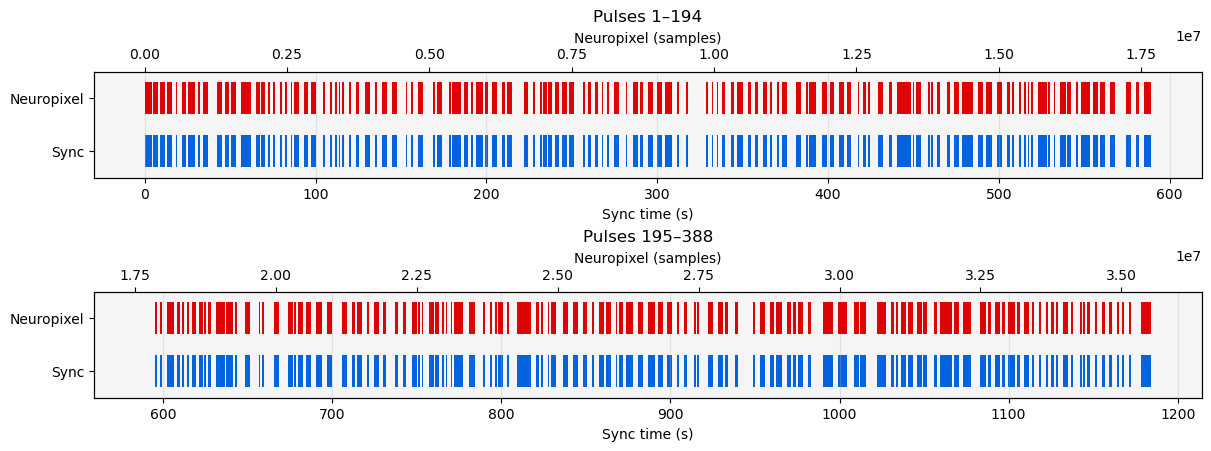

In [29]:
#==== Align pulse DataFrames ====================================================
aligned_sync_df, aligned_npx_df = get_aligned_pulse_dfs(
    sync_df=syncpulses.SyncPulseTimes,
    npx_df=npx_syncpulses.npx_pulse_durations,
    verbose=True,
    visualisation=False,
)

#==== Visualise aligned pulses with stacked plot ===============================
fig, axes = plot_stacked_pulses(
    sync_df=aligned_sync_df,
    npx_df=aligned_npx_df,
    pulses_per_row=None,
    autofit_pulses_per_row=True,
)

## **7.4 | Compute Conversion Ratio & Convert NPX Times**

`get_npx_to_bonsai_time_conversion` computes the ratio between NPX sample time and Bonsai time using the Range method (total elapsed time of matching pulses).

`convert_npx_to_bonsai_time` then applies this conversion to arbitrary NPX data (DataFrames, arrays, or Series).

Using 388 pulses. Sync start range: 0.0 -> 1184.3260159999918
Using 388 pulses. Npx start range: 0.0 -> 35529635.0
Computed NPX to Bonsai ratio (NPX_time/Bonsai_time): 29999.87716220214.
Convert using 1 / 29999.87716220214 to get Bonsai_time from NPX_time.

NPX time range: 0.0 to 35529635.0 units.
Total duration: 35529635.0 units for 388 pulses.

Bonsai time range: 0.0 to 1184.3260159999918 seconds.
Total duration: 1184.3260159999918 seconds for 388 pulses.

Converted NPX pulse times to Bonsai times:
           Start          End  Duration  State
0       0.000000     2.004975  2.004975    100
1       2.006042     3.007979  1.001937    100
2       3.010046     4.010983  1.000937    100
3       5.023021     8.034966  3.011946    100
4       9.038004    12.040949  3.002946    100
..           ...          ...       ...    ...
383  1169.239021  1169.240988  0.001967    100
384  1171.253029  1172.268000  1.014971    100
385  1175.284046  1175.286046  0.002000    100
386  1178.300025  1181.3

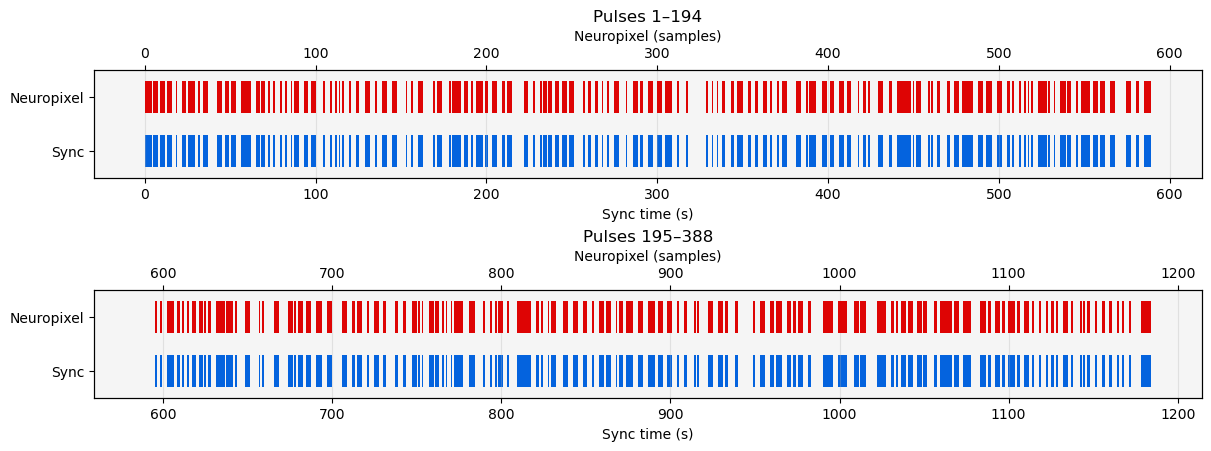

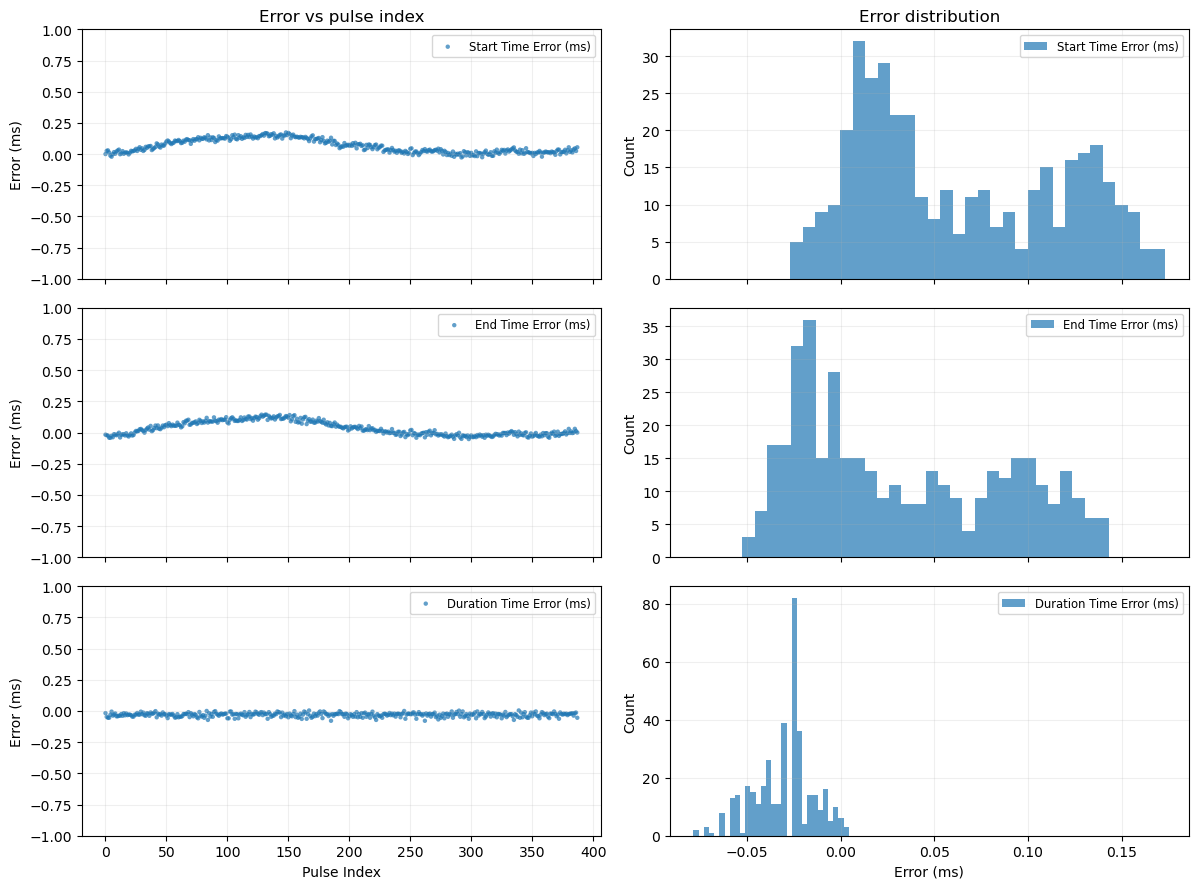

In [30]:
#==== Compute conversion ratio ==================================================
converted_npx_df, npx_to_bonsai_ratio = get_npx_to_bonsai_time_conversion(
    sync_df=syncpulses.SyncPulseTimes,
    npx_df=npx_syncpulses.npx_pulse_durations,
    visualisation=True,
    error_visualisation_tools=True,
    method='Range',
    verbose=True,
)

In [33]:
#==== Convert NPX pulse DataFrame to Bonsai time ===============================
converted_pulse_df = convert_npx_to_bonsai_time(
    npx_data=npx_syncpulses.npx_pulse_durations,
    column_names=['Start', 'End', 'Duration'],
    npx_sync_pulse=npx_syncpulses,
    sync_pulses=syncpulses,
    verbose=False,
)
print("NPX pulses converted to Bonsai time:")
display(converted_pulse_df.head(10))

#==== Convert NPX time array to Bonsai time ====================================
converted_times = convert_npx_to_bonsai_time(
    npx_data=npx_syncpulses.npx_times,
    npx_sync_pulse=npx_syncpulses,
    sync_pulses=syncpulses,
    verbose=False,
)
print(f"\nConverted NPX times array: {len(converted_times)} samples")
print(f"  First: {converted_times[0]:.4f}s,  Last: {converted_times[-1]:.4f}s")

NPX pulses converted to Bonsai time:


,Start,End,Duration,State
Pulse,,,,
0,0.000000,2.004975,2.004975,100
1,2.006042,3.007979,1.001937,100
2,3.010046,4.010983,1.000937,100
3,5.023021,8.034966,3.011946,100
4,9.038004,12.040949,3.002946,100
5,13.058987,16.072966,3.013979,100
6,18.079007,19.093978,1.014971,100
7,22.103024,23.118995,1.015971,100
8,23.120995,24.133999,1.013004,100



Converted NPX times array: 35854861 samples
  First: -8.9119s,  Last: 1186.2550s


## **7.5 | Waveform Visualisation**

`generate_waveform_from_start_end_times` generates and plots square waveforms with optional peak/trough detection, useful for visual verification of sync pulse quality.

Number of detected peaks: 385
Number of detected troughs: 386


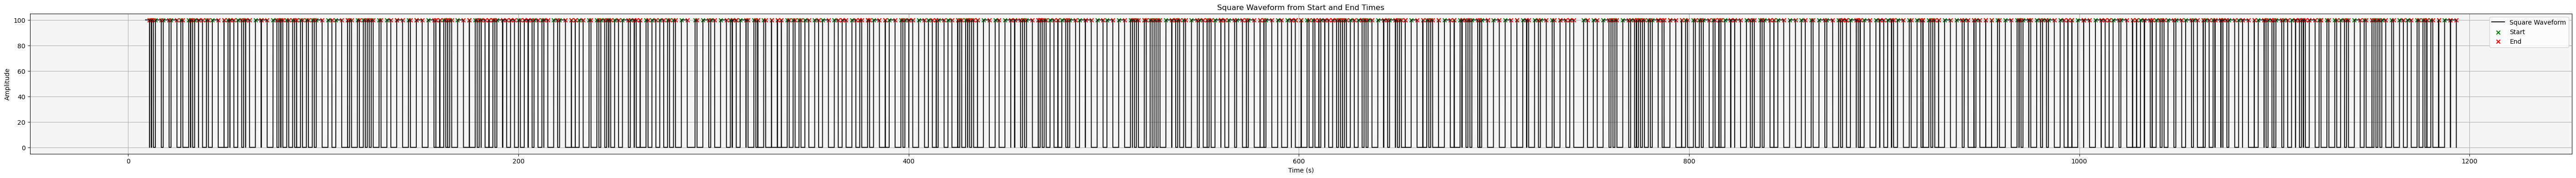

Number of detected peaks: 409
Number of detected troughs: 410


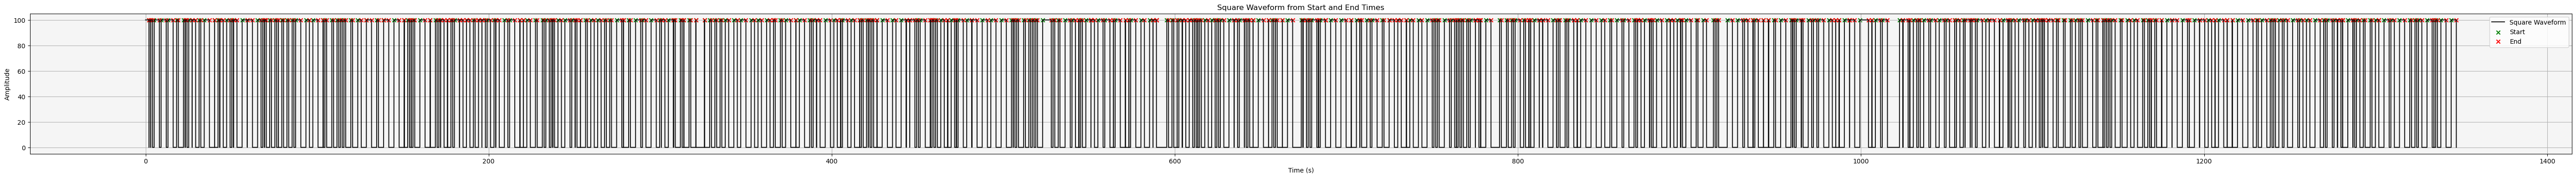

In [34]:
#==== NPX waveform visualisation ================================================
npx_pulse_df = npx_syncpulses.npx_pulse_durations
npx_waveform = generate_waveform_from_start_end_times(
    start_times=(npx_pulse_df['Start'] * (1/30000)),  # Convert samples to seconds for display
    end_times=(npx_pulse_df['End'] * (1/30000)),
    resolution=0.001,
    show_plot=True,
    peak_trough_detection=True,
    verbose=True,
)

#==== Bonsai waveform visualisation ============================================
bonsai_waveform = generate_waveform_from_start_end_times(
    start_times=syncpulses.SyncPulseTimes['Start'],
    end_times=syncpulses.SyncPulseTimes['End'],
    resolution=0.001,
    show_plot=True,
    peak_trough_detection=True,
    verbose=True,
)

# **Part 8: Full Session Workflow — Combining All Modules**
-----

This section demonstrates how to combine all the refactored modules into a single, reusable session-processing workflow. The `Bonsai_DefaultSession` class below acts as an orchestrator that loads all relevant data from a single experimental directory.

This is an example of how users can build upon the toolkit to create their own modular workflows tailored to their specific experimental setup.

In [35]:
class Bonsai_DefaultSession:
    '''
    Example session orchestrator that loads all available data components from
    a single Bonsai experimental directory using the refactored modules.

    Parameters
    ----------
    experiment_directory_path : str
        Path to the Bonsai experiment directory.
    harp_device_yaml_path : str
        Path to the main harp device YAML schema.
    soundcard_yaml_path : str
        Path to the SoundCard YAML schema.
    nosepoke_config : dict
        Configuration for Nosepoke (virtual_maps, device_list, etc.)
    components : dict
        Boolean flags for which components to load.
    verbose : bool
        Verbose output.
    '''
    def __init__(self,
                 experiment_directory_path=None,
                 harp_device_yaml_path='./device.yml',
                 soundcard_yaml_path='./soundcard.yml',
                 nosepoke_config=None,
                 components=None,
                 verbose=False):

        self.experiment_directory_path = experiment_directory_path
        self.harp_device_yaml_path = harp_device_yaml_path
        self.soundcard_yaml_path = soundcard_yaml_path
        self.verbose = verbose
        self.results = {}

        if components is None:
            components = {
                'ExperimentEvents': True,
                'Nosepoke': True,
                'SoundCard': True,
                'CameraStart': True,
                'CameraFrames': True,
                'RotationData': True,
                'VideoData': True,
                'VisualEnvironment': True,
                'SessionSettings': True,
            }

        #==== ExperimentEvents =================================================
        if components.get('ExperimentEvents'):
            try:
                self.ExperimentEvents = ExperimentEvents(
                    experiment_directory_path=self.experiment_directory_path,
                    verbose=self.verbose,
                )
                self.results['ExperimentEvents'] = self.ExperimentEvents.df
                if self.verbose:
                    print(f"✓ ExperimentEvents: {self.ExperimentEvents.df.shape}")
            except Exception as e:
                print(f"✗ ExperimentEvents failed: {e}")

        #==== Nosepoke =========================================================
        if components.get('Nosepoke') and nosepoke_config is not None:
            try:
                self.Nosepoke = Nosepoke(
                    experiment_directory_path=self.experiment_directory_path,
                    harp_device_yaml_path=self.harp_device_yaml_path,
                    **nosepoke_config,
                    verbose=self.verbose,
                )
                self.results['Nosepoke'] = {
                    'data_arrays': self.Nosepoke.data_arrays,
                    'lookup_arrays': self.Nosepoke.lookup_arrays,
                    'reference_dicts': self.Nosepoke.reference_dicts,
                }
                if self.verbose:
                    print(f"✓ Nosepoke: {list(self.Nosepoke.data_arrays.keys())}")
            except Exception as e:
                print(f"✗ Nosepoke failed: {e}")

        #==== SoundCard ========================================================
        if components.get('SoundCard'):
            try:
                self.SoundCard = SoundCard(
                    experiment_directory_path=self.experiment_directory_path,
                    harp_device_yaml_path=self.soundcard_yaml_path,
                    verbose=self.verbose,
                )
                self.results['SoundCard'] = self.SoundCard.device_da_dict
                if self.verbose:
                    print(f"✓ SoundCard: {list(self.SoundCard.device_da_dict.keys())}")
            except Exception as e:
                print(f"✗ SoundCard failed: {e}")

        #==== CameraStart ======================================================
        if components.get('CameraStart'):
            try:
                self.CameraStart = CameraStart(
                    experiment_directory_path=self.experiment_directory_path,
                    harp_device_yaml_path=self.harp_device_yaml_path,
                    verbose=self.verbose,
                )
                self.results['CameraStart'] = self.CameraStart.device_da_dict
                if self.verbose:
                    print(f"✓ CameraStart: {list(self.CameraStart.device_da_dict.keys())}")
            except Exception as e:
                print(f"✗ CameraStart failed: {e}")

        #==== CameraFrames =====================================================
        if components.get('CameraFrames'):
            try:
                self.CameraFrames = Camera0Frames(
                    experiment_directory_path=self.experiment_directory_path,
                    harp_device_yaml_path=self.harp_device_yaml_path,
                    verbose=self.verbose,
                )
                self.results['CameraFrames'] = self.CameraFrames.device_da_dict
                if self.verbose:
                    print(f"✓ CameraFrames: {list(self.CameraFrames.device_da_dict.keys())}")
            except Exception as e:
                print(f"✗ CameraFrames failed: {e}")

        #==== RotationData =====================================================
        if components.get('RotationData'):
            rotation_types = ['InnerRotation', 'OuterRotation', 'NosepokeRotation']
            self.results['RotationData'] = {}
            for rot_type in rotation_types:
                try:
                    rot = RotationData(
                        experiment_directory_path=self.experiment_directory_path,
                        device_type=rot_type,
                        verbose=self.verbose,
                    )
                    self.results['RotationData'][rot_type] = rot.df
                    if self.verbose:
                        print(f"✓ {rot_type}: {rot.df.shape}")
                except Exception as e:
                    if self.verbose:
                        print(f"✗ {rot_type}: {e}")

        #==== VideoData ========================================================
        if components.get('VideoData'):
            try:
                self.VideoData = VideoData(
                    experiment_directory_path=self.experiment_directory_path,
                    verbose=self.verbose,
                )
                self.results['VideoData'] = self.VideoData.df
                if self.verbose:
                    print(f"✓ VideoData: {self.VideoData.df.shape}")
            except Exception as e:
                print(f"✗ VideoData failed: {e}")

        #==== VisualEnvironment ================================================
        if components.get('VisualEnvironment'):
            try:
                self.VisualEnvironment = VisualEnvironment(
                    experiment_directory_path=self.experiment_directory_path,
                    verbose=self.verbose,
                )
                self.results['VisualEnvironment'] = self.VisualEnvironment.df
                if self.verbose:
                    print(f"✓ VisualEnvironment: {self.VisualEnvironment.df.shape}")
            except Exception as e:
                print(f"✗ VisualEnvironment failed: {e}")

        #==== SessionSettings ==================================================
        if components.get('SessionSettings'):
            try:
                self.SessionSettings = FileTypeData(
                    experiment_directory_path=self.experiment_directory_path,
                    device_type='SessionSettings',
                    file_type='jsonl',
                    verbose=self.verbose,
                )
                self.results['SessionSettings'] = self.SessionSettings.df
                if self.verbose:
                    print(f"✓ SessionSettings loaded")
            except Exception as e:
                print(f"✗ SessionSettings failed: {e}")

        if self.verbose:
            print(f"\n{'='*60}")
            print(f"Session loaded: {len(self.results)} components")
            print(f"Available: {list(self.results.keys())}")

print("Bonsai_DefaultSession class defined.")

Bonsai_DefaultSession class defined.


In [36]:
#==== Nosepoke configuration dict (reuse from Part 4) ==========================
nosepoke_config = dict(
    virtual_maps=virtual_maps,
    global_coord_name='peripherals',
    virtual_coord_names=['device', 'register', 'localID'],
    dict_of='dicts',
    data_keys=list(channel_type_localIDs.keys()),
    data_registerIDs=channel_type_registerIDs,
    device_type='Behavior',
    device_list=device_list,
    device_registers_dict=device_registers_dict,
)

#==== Run the full session workflow ============================================
session = Bonsai_DefaultSession(
    experiment_directory_path=experiment_directory_path,
    harp_device_yaml_path=harp_device_yaml_path,
    soundcard_yaml_path=soundcard_yaml_path,
    nosepoke_config=nosepoke_config,
    verbose=True,
)

Searching for csv files in Bonsai_logs/2025-10-07T18-08-45/ExperimentEvents
Searching for *.csv files in Bonsai_logs/2025-10-07T18-08-45/ExperimentEvents found 1 files.
Found csv file: Bonsai_logs/2025-10-07T18-08-45/ExperimentEvents/ExperimentEvents_1904-01-02T05-00-00.csv
Using provided csv_kwargs:  {'header': 0, 'dtype': <class 'str'>, 'engine': 'python', 'sep': ',(?![^{]*})', 'index_col': 0}
Loaded DataFrame shape:  (47, 1)
Renamed columns: {'Value': 'Event'}
Renamed index: Time
ExperimentEvents data loaded successfully.
ExperimentEvents full DataFrame shape:  (47, 1)
✓ ExperimentEvents: (47, 1)

--- Processing devices and registers ---

Processing device: Behavior0
  - Loaded register TimestampSeconds (address 8) with shape (1313, 1)
  - Loaded register DigitalInputState (address 32) with shape (8, 4)
  - Loaded register OutputSet (address 34) with shape (424, 14)
  - Loaded register OutputClear (address 35) with shape (447, 14)
  - Loaded register AnalogData (address 44) with sha

In [37]:
#==== Inspect session results ===================================================
for key in session.results.keys():
    print(f'\n{"="*60}')
    print(f'{key}')
    print(f'{"="*60}')

    result = session.results[key]

    if key == 'Nosepoke':
        for subkey in result.keys():
            print(f'\n  --- {subkey} ---')
            if subkey == 'data_arrays':
                for tk, da in result[subkey].items():
                    print(f'    {tk}: shape={da.shape}')
                    display(da.to_dataframe().head(3))
            elif subkey == 'lookup_arrays':
                for tk, la in result[subkey].items():
                    print(f'    {tk}:')
                    display(la[0].to_dataframe().reset_index().head(6))
            elif subkey == 'reference_dicts':
                display(result[subkey])

    elif key == 'RotationData':
        for rot_type, df in result.items():
            print(f'  {rot_type}: {df.shape}')
            display(df.head(3))

    elif isinstance(result, pd.DataFrame):
        print(f'  Shape: {result.shape}')
        display(result.head(5))

    elif isinstance(result, dict):
        if 'metadata' in result:
            display(result['metadata'])
        else:
            for subkey, val in result.items():
                print(f'\n  --- {subkey} ---')
                if hasattr(val, 'to_dataframe'):
                    display(val.to_dataframe().head(3))
                else:
                    display(val)


ExperimentEvents
  Shape: (47, 1)


,Event
Time,
104986.954976,Request camera start
104989.209984,Start Sync Pulse
105065.489984,Start trial logic
105065.744000,Trial start
105065.744000,Rotating nosepoke



SoundCard

  --- PlaySoundFreq ---


,PlaySoundOrFrequency
Time,
29017.929504,880
29017.930112,880
29317.986496,880



  --- StopLog ---


...

,Rotation
Time,
104986.180000,0
104987.186976,0
104988.178976,0


  NosepokeRotation: (1300, 1)


,Rotation
Time,
104986.976992,0
104987.984992,0
104988.976992,0



SessionSettings


,arenaCenter,innerRingRadius,innerRingDistance,outerRingRadius,nosepokeDistance,overlayLayerOn,screenDivisions,actuatorRateLimit,loggingRootPath,nosepokeRotationTolerance,ringRotationTolerance,overlayLayerOff,ringHomingCommand,syncPulseLimits,animalId,nosepokeHomingCommand.position,nosepokeHomingCommand.acceleration,nosepokeHomingCommand.deceleration,nosepokeHomingCommand.velocity
0,"[395, 290]",165.0,10.0,250.0,50.0,10,30,0.2,C:\Users\Keshavarzi lab\LogData,0.1,0.1,0,"[{'position': 0.0, 'acceleration': 300.0, 'dec...","[0.5, 3.0]",plimbo,0.0,100.0,100.0,20.0


# **Summary**
-----

This notebook demonstrated the complete refactored workflow across **7 modules**:

| Part | Module | Key Imports | What it Does |
|------|--------|------------|--------------|
| 1 | `HarpExtender` | `construct_device_reader`, `collect_device_folders`, `collect_registers`, `collect_device_dfs` | Read harp YAML schemas, discover device folders, extract register DataFrames |
| 2 | `Timestamps` | `collect_timestamps`, `collect_timestamps_dict`, `collect_timestamps_nested_dict` | Extract and collate timestamps from DataFrames and nested dicts |
| 3 | `LookupArrays` | `construct_data_array`, `construct_lookup_array`, `ulookup`, `update_data_array`, `CDLAccessor` | Build, query, and populate xarray DataArrays with virtual coordinate metadata |
| 4 | `MultiDevices` | `Nosepoke`, `BehaviorNosepoke` | Orchestrate the full pipeline for multi-device peripheral data |
| 5 | `Devices` | `SoundCard`, `CameraStart`, `Camera0Frames`, `AnalogSync` | Pre-configured single-device DataArray extraction |
| 6 | `Filetypes` | `ExperimentEvents`, `RotationData`, `VideoData`, `VisualEnvironment`, `RingDebugData`, `FileTypeData` | Load non-Harp data files (CSV, JSONL, YAML) |
| 7 | `Alignment_Utils` | `DigitalSyncPulse`, `Npx_SyncPulse`, `get_aligned_pulse_dfs`, `get_npx_to_bonsai_time_conversion`, `convert_npx_to_bonsai_time`, `plot_stacked_pulses` | Sync pulse extraction, time conversion, and visualisation |

**Part 8** showed how all modules can be combined into a reusable `Bonsai_DefaultSession` class for processing entire experimental sessions with minimal user configuration.